# Aprendizaje online y gradiente descendente estocástico
## Definición del problema de estimación de parámetros

Se desean encontra los parámetros w_0 y w_1 del siguiente modelo de regresión entre las variables x y y:

$$y_i = w_1 x_i + w_0 + e_i$$

a partir de un conjunto de observaciones $\{d_i, x_i\}$, donde d_i es el valor real (observado), y_i es su aproximación usando el modelo de regresión descrito, y e_i es el error.

ya sabemos que 

La sumatoria de errores al cuadrado es definido como:

$$\text{SSE}(w_0, w_1) = \sum_i (d_i - y_i)^2$$

Si se tiene en cuenta que el error instantáneo se define como:

$$e_i = d_i - y_i$$

la ecuación anterior se puede reescribir como:

\begin{split} \text{SSE}(w_0, w_1) & = \sum_i (d_i - y_i)^2 \\ & = \sum_i e_i^2 \end{split}

## Con el aprendizaje batch (cálculo por medio del método del gradiente descendente)

\begin{split} \mathbf{w}_k & = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1}) \\ & = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \left( \sum_i e_i^2 \right) \end{split}

donde $\mathbf{w} = [w_0, w_1]$.

La ecuación anterior se puede reescribir como:

$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \sum_i \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right)$$

que es calculando la derivada en cada punto específico de error. 

## Aprendizaje online
El aprendizaje online se obteiene al hacer una corrección de los parámetros de forma secuencial para cada punto $i$. El nombre se deriva del hecho de que los puntos

$$(x_i,y_i)$$

pueden presentarse al algoritmo como un stream de datos.

Es decir, la ecuación de corrección cambia a:

$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right)$$

el proceso es el siguiente:

* Se computa el gradiente instantáneo para el punto i. (calcular derivada)

* Se realiza la corrección del vector de parámetros $\mathbf{w}_k$ con el gradiente para el punto i.

* Se pasa al siguiente punto (i = i + 1) y se rotorna al primer paso.

en este caso se necesitan las derivadas instantáneas las cuales son: 

\begin{split} \frac{\partial}{\partial w_0} e^2_i & = -2 e_i \\ \end{split}

\begin{split} \frac{\partial}{\partial w_1} e^2_i & = -2 e_i x_i \\ \end{split}





In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

In [13]:
#
# Datos del problema
#
x_sample = [
    0.6231,
    0.7460,
    0.1087,
    0.3654,
    0.3065,
    0.6886,
    0.4966,
    0.2618,
    0.7607,
    0.4424,
    0.7731,
]

y_sample = [
    1.6266,
    1.8508,
    0.9519,
    1.2828,
    1.2283,
    1.8722,
    1.4657,
    1.1097,
    1.7826,
    1.4267,
    1.8248,
]

In [14]:
#
# Sumatoria del error cuadrático o pérdida cuadrática
#
def sse(w0, w1):
    y_forecasts = [w0 + w1 * x_value for x_value in x_sample]
    errors = [y_true - y_forecast for y_true, y_forecast in zip(y_sample, y_forecasts)]
    squared_errors = [error ** 2 for error in errors]
    return sum(squared_errors)

In [15]:
def plot_contour():

    W0 = np.linspace(0.0, 0.8, 50)
    W1 = np.linspace(2.4, 3.2, 50)
    W0, W1 = np.meshgrid(W0, W1)
    F = sse(W0, W1)

    levels = [0, 0.2, 0.5, 0.75, 1, 2, 3, 5, 10, 20, 40, 60]

    fig, ax = plt.subplots(figsize=(3.5, 3.5))

    ax.set_aspect("equal", "box")
    ax.contourf(W0, W1, F, cmap=cm.Greys, levels=levels, alpha=0.8)
    ax.contour(W0, W1, F, colors="gray", levels=levels)
    ax.grid()
    ax.set_xlabel("w0")
    ax.set_ylabel("w1")

In [16]:
def gradient(w0, w1, x_value, y_value):

    error = y_value - w0 - w1 * x_value
    #notese que las formulas salen explíticasa
    #como dervicadas analíticas.
    gradient_w0 = -2 * error
    gradient_w1 = -2 * error * x_value

    return gradient_w0, gradient_w1

Ecuación de mejora
$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right)$$

In [17]:
def improve(w0, w1, mu, x_value, y_value):

    gradient_w0, gradient_w1 = gradient(w0, w1, x_value, y_value)
    w0 = w0 - mu * gradient_w0
    w1 = w1 - mu * gradient_w1

    return w0, w1

 w0 = 0.2106
 w1 = 2.4542
SSE = 0.6276



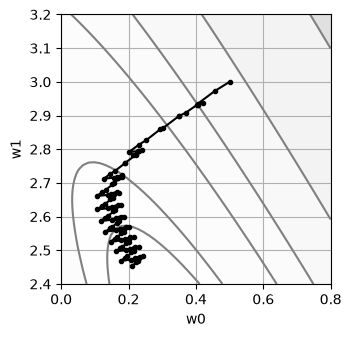

In [18]:
# proceso iterativo del aprendizaje online
#
# Punto de inicio
#
w0 = 0.5
w1 = 3.0

history = {
    "w0": [w0],
    "w1": [w1],
    "sse": [sse(w0, w1)],
}

mu = 0.03

for epoch in range(10):

    for x_value, y_value in zip(x_sample, y_sample):

        w0, w1 = improve(w0, w1, mu, x_value, y_value)

        history["w0"].append(w0)
        history["w1"].append(w1)
        history["sse"].append(sse(w0, w1))

print(" w0 = {:6.4f}\n w1 = {:6.4f}\nSSE = {:6.4f}\n".format(w0, w1, sse(w0, w1)))

plot_contour()
plt.plot(history["w0"], history["w1"], marker=".", color="black")
plt.show()

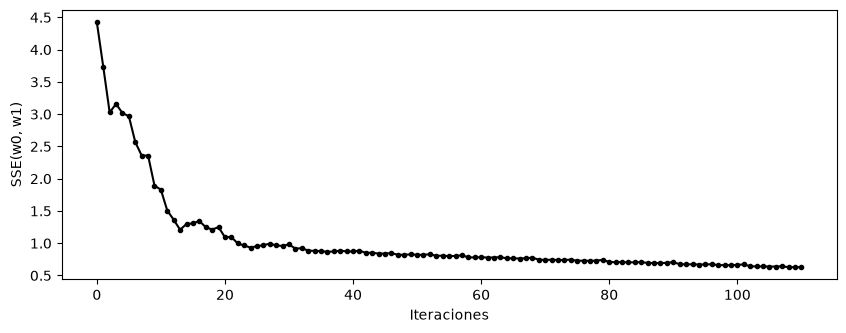

In [19]:
# reduccción de la suma del cuadrado de los residuos al incrementar 
#las iteraciones
plt.figure(figsize=(10, 3.5))
plt.plot(history["sse"], ".-k")
plt.xlabel("Iteraciones")
plt.ylabel("SSE(w0, w1)")
plt.show()

El descenso por gradiente online se diferencia del descednso por gradiente tradicional en la cantidad de datos que procesa para realizar una sola actualización de los parámetros. 

Batch Gradient Descent (Tradicional): Espera a procesar TODO el conjunto de datos de entrenamiento para calcular el gradiente global y hacer una sola actualización de los pesos. Por eso es es que el cálculo del vector gradiente se hace sobre la suma del cuadrado de los residuos

\begin{split} \mathbf{w}_k & = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1}) \\ & = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \left( \sum_i e_i^2 \right) \end{split}

En su lugar, Online Gradient Descent: Procesa UN SOLO dato a la vez. Inmediatamente calcula la pérdida, actualiza los pesos y descarta (o pasa al siguiente) ese dato. Como es de a un solo dato por ello es que pueden llegar los demás de a uno. Como online

Datos masivos o en Streaming: Si tus datos no caben en la memoria RAM o llegan constantemente en tiempo real (por ejemplo, clics de usuarios en una web), el enfoque Online es la única opción viable, ya que el modelo "aprende sobre la marcha".



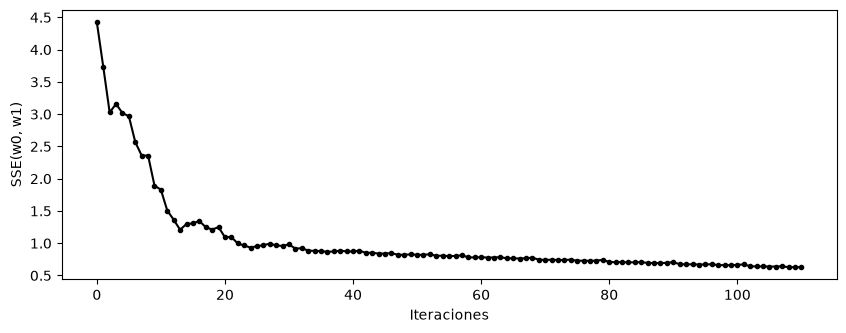

In [20]:
# Visualización del historial de SSE
plt.figure(figsize=(10, 3.5))
plt.plot(history["sse"], ".-k")
plt.xlabel("Iteraciones")
plt.ylabel("SSE(w0, w1)")
plt.show()

## Gradiente descendente estocástico
El método de gradiente descendente estocástico es el método de aprendizaje online (el anterior) en que los patrones se recorren de manera aleatoria. 

 w0 = 0.2161
 w1 = 2.4524
SSE = 0.6220



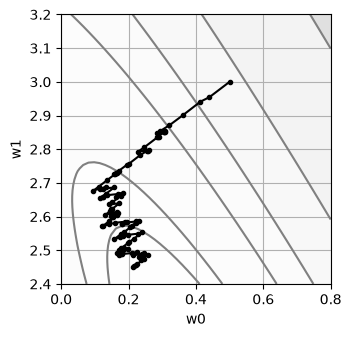

In [21]:
#
# Punto de inicio
#
w0 = 0.5
w1 = 3.0

history = {
    "w0": [w0],
    "w1": [w1],
    "sse": [sse(w0, w1)],
}

mu = 0.03

n_samples = len(x_sample)

for epoch in range(10):

    # Acá notese que se toman las muestras de manera aleatoria, sin reemplazo,
    #  para que no se repitan en la misma iteración pero se garantiza que se 
    # recorran todos los puntos a diferencia del online
    # que se hace de manera secuencial.
    for n in np.random.choice(n_samples, n_samples, replace=False):

        w0, w1 = improve(w0, w1, mu, x_sample[n], y_sample[n])

        history["w0"].append(w0)
        history["w1"].append(w1)
        history["sse"].append(sse(w0, w1))

print(" w0 = {:6.4f}\n w1 = {:6.4f}\nSSE = {:6.4f}\n".format(w0, w1, sse(w0, w1)))

# ver la curvas de nivel. 
plot_contour()
plt.plot(history["w0"], history["w1"], marker=".", color="black");

In [22]:
#función para haacer una selección de manera aleatoria de los elementos de un arreglo sin reemplazo
np.random.choice(10,10,replace=False)

array([8, 4, 9, 2, 7, 3, 5, 0, 1, 6])

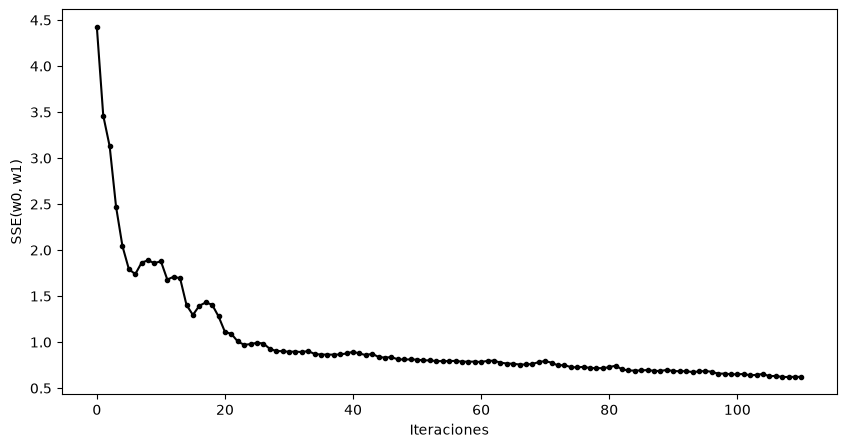

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(history["sse"], ".-k")
plt.xlabel("Iteraciones")
plt.ylabel("SSE(w0, w1)")
plt.show()

Nota: 
El aprendizaje batch converge más rapidamente pero converge en púntos de mínimo local lo cúal puede verse con el método SSE

Mientras que el gradiente descendente estocástico puede saltar estos mínimos locales saltando de diferentes puntos

# Aprendizaje Minibatch
## Definición del problema de estimación de parámetros y función de pérdida. 

Se desean encontra los parámetros w_0 y w_1 del siguiente modelo de regresión entre las variables x y y:

$$y_i = w_1 x_i + w_0 + e_i$$

a partir de un conjunto de observaciones $\{d_i, x_i\}$, donde d_i es el valor real (observado), y_i es su aproximación usando el modelo de regresión descrito (valor ajustado), y e_i es el error.

Error instantáneo:

$$e_i = d_i - y_i \text{real - ajustado}$$ 

Sumatoria del error cuadrático instantáneo:

$$\begin{split} \text{SSE}(w_0, w_1) & = \sum_i (d_i - y_i)^2 \\ & = \sum_i e_i^2 \end{split}$$

## Versiones del método del gradiente

Aprendizaje Online: Tomando el error puntual donde el valor de pendiente e intercepto son diferentes. 

$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right)$$

Aprendizaje Batch: En este se calcula la derivada de todo el error de tal manera ue se evalua el data set con los mismos valores de pendiente e intercepto. 

\begin{split} \mathbf{w}_k & = \mathbf{w}_{k-1} - \mu \sum_i \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right) \end{split}

## Minibatch

Para conjuntos de datos muy grandes el aprendizaje batch es muy costoso computacionalmente ya que deben recorrerse todos los datos, mientras que el aprendizaje online es muy lento en converger. Es en este caso, donde se toma un punto intermedio:

* El conjunto de datos se divide en varios subconjuntos.

* Se ordenan aleatoriamente los subconjuntos de datos y luego se recorren uno a uno, tal como en el caso del gradiente descendente estocástico.

* Para el subconjunto actual, se computa el gradiente neto (tal como en el caso del aprendizaje batch) y se corrigen los parámetros.

* Se repite nuevamente el proceso hasta que el algoritmo converga.

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

In [25]:
#
# Dataset
#
x_sample = [
    0.1087,
    0.2698,
    0.3765,
    0.2146,
    0.9155,
    0.0246,
    0.0221,
    0.8632,
    0.6460,
    0.2092,
    0.8567,
    0.1591,
    0.9647,
    0.6231,
    0.7460,
    0.3654,
    0.3065,
    0.6886,
    0.4966,
    0.2008,
    0.2618,
    0.7607,
    0.1563,
    0.4424,
    0.7731,
]

y_sample = [
    0.9519,
    1.1237,
    1.2360,
    1.0526,
    2.0743,
    0.7906,
    0.7603,
    2.0533,
    1.6887,
    1.0563,
    2.0991,
    0.8953,
    2.1917,
    1.6266,
    1.8508,
    1.2828,
    1.2283,
    1.8722,
    1.4657,
    1.0418,
    1.1097,
    1.7826,
    0.9711,
    1.4267,
    1.8248,
]

In [26]:
#
# Función auxiliar para computar el SSE
#
#
# Sumatoria del error cuadrático o pérdida cuadrática
#
def sse(w0, w1):
    #pronósticos para cada valor de x en la muestra
    y_forecasts = [w0 + w1 * x_value for x_value in x_sample]

    # residuales
    errors = [y_true - y_forecast for y_true, y_forecast in zip(y_sample, y_forecasts)]

    # errores al cuadrado
    squared_errors = [error ** 2 for error in errors]

    # suma de los errores al cuadrado
    return sum(squared_errors)

In [27]:
#
# Función auxililar para graficar el contorno
#
def plot_contour():

    W0 = np.linspace(0.0, 2.0, 50)
    W1 = np.linspace(1.5, 3.2, 50)
    W0, W1 = np.meshgrid(W0, W1)
    F = sse(W0, W1)

    levels = [0, 0.2, 0.5, 0.75, 1, 2, 3, 5, 10, 20, 40, 60, 80, 100, 120]

    fig, ax = plt.subplots(figsize=(3.5, 3.5))

    ax.set_aspect("equal", "box")
    ax.contourf(W0, W1, F, cmap=cm.Greys, levels=levels, alpha=0.8)
    ax.contour(W0, W1, F, colors="gray", levels=levels)
    ax.grid()
    ax.set_xlabel("w0")
    ax.set_ylabel("w1")

In [28]:
#
# Esta es el mismo computo que el empleado en el
# método batch.
#
def gradient(w0, w1, indices):

    x_batch = x_sample[indices]
    y_batch = y_sample[indices]

    y_forecasts = [w0 + w1 * x_value for x_value in x_batch]

    errors = [y_true - y_forecast for y_true, y_forecast in zip(y_batch, y_forecasts)]

    gradient_w0 = -2 * sum(errors)
    gradient_w1 = -2 * sum([error * x_value for error, x_value in zip(errors, x_batch)])

    return gradient_w0, gradient_w1

In [29]:
def improve(w0, w1, mu, indices):

    gradient_w0, gradient_w1 = gradient(w0, w1, indices)

    w0 = w0 - mu * gradient_w0
    w1 = w1 - mu * gradient_w1

    return w0, w1

In [30]:
n_batches = 5
batch_indices = np.array_split(np.array(range(len(x_sample))), n_batches)
batch_indices

[array([0, 1, 2, 3, 4]),
 array([5, 6, 7, 8, 9]),
 array([10, 11, 12, 13, 14]),
 array([15, 16, 17, 18, 19]),
 array([20, 21, 22, 23, 24])]

 w0 = 0.6118
 w1 = 1.6921
SSE = 0.1564



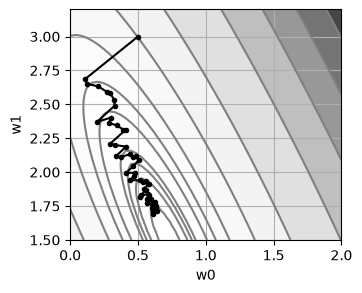

In [31]:
#
# Punto de inicio
#
w0 = 0.5
w1 = 3.0

history = {
    "w0": [w0],
    "w1": [w1],
    "sse": [sse(w0, w1)],
}

mu = 0.05

x_sample = np.array(x_sample)
y_sample = np.array(y_sample)

for epoch in range(10):

    for i_group in np.random.choice(n_batches, n_batches, replace=False):

        indices = list(batch_indices[i_group])

        w0, w1 = improve(w0, w1, mu, indices)

        history["w0"].append(w0)
        history["w1"].append(w1)
        history["sse"].append(sse(w0, w1))

print(" w0 = {:6.4f}\n w1 = {:6.4f}\nSSE = {:6.4f}\n".format(w0, w1, sse(w0, w1)))

plot_contour()
plt.plot(history["w0"], history["w1"], marker=".", color="black")
plt.show()

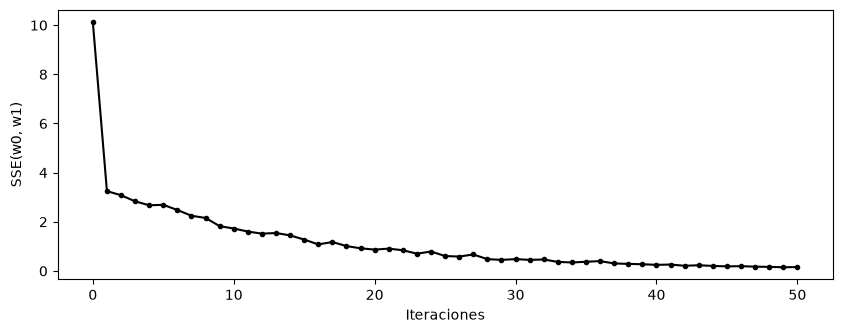

In [32]:
plt.figure(figsize=(10, 3.5))
plt.plot(history["sse"], ".-k")
plt.xlabel("Iteraciones")
plt.ylabel("SSE(w0, w1)")
plt.show()

# Regla delta generalizada y algoritmos con supermemoria.
En el algoritmo de gradiente descendente, el proceso de optimización usa la siguiente ecuación recursiva:

$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} f(\mathbf{w}_{k-1})$$

Como caso de aplicación se desea ajustar el modelo de regresión lineal

$$y_i = w_0 + w_1 * x_i$$

al siguiente conjunto de datos:



In [33]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

In [34]:
x_sample = np.array(
    [
        0.1087,
        0.2698,
        0.3765,
        0.2146,
        0.9155,
        0.0246,
        0.0221,
        0.8632,
        0.6460,
        0.2092,
        0.8567,
        0.1591,
        0.9647,
        0.6231,
        0.7460,
        0.3654,
        0.3065,
        0.6886,
        0.4966,
        0.2008,
        0.2618,
        0.7607,
        0.1563,
        0.4424,
        0.7731,
    ]
)

y_sample = np.array(
    [
        0.9519,
        1.1237,
        1.2360,
        1.0526,
        2.0743,
        0.7906,
        0.7603,
        2.0533,
        1.6887,
        1.0563,
        2.0991,
        0.8953,
        2.1917,
        1.6266,
        1.8508,
        1.2828,
        1.2283,
        1.8722,
        1.4657,
        1.0418,
        1.1097,
        1.7826,
        0.9711,
        1.4267,
        1.8248,
    ]
)

Para ello, se usa como función de pérdida la sumatoria del error cuadrático (SSE) definda como:

$$\text{SSE}(w_0, w_1) = \sum_i (d_i - w_0 - w_1 x_i)^2$$

In [35]:
def sse(w0, w1):
    y_forecasts = [w0 + w1 * x_value for x_value in x_sample]
    errors = [y_true - y_forecast for y_true, y_forecast in zip(y_sample, y_forecasts)]
    squared_errors = [error ** 2 for error in errors]
    return sum(squared_errors)

Como ya se explicó, la función SSE() es una cuadrática con forma de tazón y un único punto de mínima que corresponde al valor óptimo de los parámetros w_0 y w_1. La gráfica de la cuadrática es presentada a continuación.

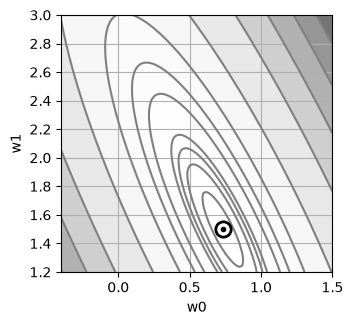

In [36]:
def plot_contour():

    W0 = np.linspace(-0.4, 1.5, 100)
    W1 = np.linspace(1.2, 3.0, 100)
    W0, W1 = np.meshgrid(W0, W1)
    F = sse(W0, W1)

    levels = [0, 0.2, 0.5, 0.75, 1, 2, 3, 5, 10, 20, 30, 40, 50, 60]

    _, ax = plt.subplots(figsize=(3.5, 3.5))
    ax.set_aspect("equal", "box")
    ax.contourf(W0, W1, F, cmap=cm.Greys, levels=levels, alpha=0.6)
    ax.contour(W0, W1, F, colors="gray", levels=levels)
    plt.plot(
        [0.731],
        [1.498],
        "o",
        color="black",
        fillstyle="none",
        markersize=11,
        markeredgewidth=2,
    )
    plt.plot([0.731], [1.498], ".", color="black")
    ax.set_xlabel("w0")
    ax.set_ylabel("w1")
    ax.grid()


plot_contour()

Tal como ya se habia explicado, la técnica del gradiente descendente se basa en un proceso iterativo que usa la siguiente ecuación para refinar la aproximación al valor óptimo de los parámetros:

$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1})$$

con:

$$\frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}) = \left[ \begin{array}{c} -2 \sum_i e_i \\ -2 \sum_i e_i x_i \end{array} \right]$$

Estos cómputos son implementados a continuación.

In [37]:
def gradient(w0, w1):
    y_forecasts = [w0 + w1 * x_value for x_value in x_sample]
    errors = [y_true - y_forecast for y_true, y_forecast in zip(y_sample, y_forecasts)]
    gradient_w0 = -2 * sum(errors)
    gradient_w1 = -2 * sum(
        [error * x_value for error, x_value in zip(errors, x_sample)]
    )
    return gradient_w0, gradient_w1

In [38]:
def improve(w0, w1, mu):
    gradient_w0, gradient_w1 = gradient(w0, w1)
    w0 = w0 - mu * gradient_w0
    w1 = w1 - mu * gradient_w1
    return w0, w1

El proceso de optimización se realiza de un punto inicial arbitrario. A continuación se presenta el valor encontrado y la traza de puntos que recorre el algoritmo hasta llegar al óptimo.

 w0 = 0.6786
 w1 = 1.6341
SSE = 0.0924


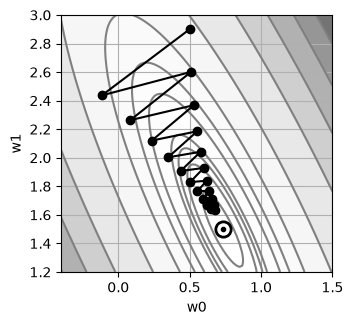

In [39]:
# Punto de inicio
w0 = 0.5
w1 = 2.9

history_gd = {
    "w0": [w0],
    "w1": [w1],
    "sse": [sse(w0, w1)],
}

mu = 0.03

for epoch in range(20):

    w0, w1 = improve(w0, w1, mu)

    history_gd["w0"].append(w0)
    history_gd["w1"].append(w1)
    history_gd["sse"].append(sse(w0, w1))

print(" w0 = {:6.4f}\n w1 = {:6.4f}\nSSE = {:6.4f}".format(w0, w1, sse(w0, w1)))

plot_contour()
plt.plot(history_gd["w0"], history_gd["w1"], marker="o", color="black")
plt.show()

Note que el algoritmo realiza una caminata en zigzag (va y se devuelve) intentando llegar al óptimo. Este comportamiento es indeseable y se desea evitar el zigzag ya que se desperdician iteraciones para llegar al óptimo.

Sería mucho más conveniente avanzar en una recta, esto es lo que se pretende con la regla del tag generalizada. La diferencia entre este método y el descenso por gradiente es que en el descenso por gradiente se tiene la dirección del vector que sale (rojo) y hacia donde va (azul), pero notemos que podemos movernos entre esos puntos de una manera más optima tomando la dirección de verde. 

![direccion](../../imagenes/direccion.png)

# Algoritmo momentum
Para evitar el zigzag, se desea usar la dirección del gradiente actual (azul) ponderada por la dirección previa(rojo). Esta metodología se conoce como regla delta (en la jerga de redes neuronales artificiales) o gradiente con memoria (en investigación de operaciones).

Específicamente, el proceso de optimización se basa en la siguiente ecuación recursiva (ya estudiada):

$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1})$$

a cual que puede ser reescrita como:

$$\mathbf{w}_k = \mathbf{w}_{k-1} + \Delta \mathbf{w}_{k-1}$$

con:

$$\Delta \mathbf{w}_{k-1} = - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1})$$

La dirección tomada en la iteración anterior será $\Delta$ $$\mathbf{w}_{k-2}$$. Ahora, solo es necesario agregar este término a la ecuación anterior, ponderado por un parámetro $\beta$ conocido comúnmente como momentum:

$$\Delta \mathbf{w}_{k-1} = - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1}) + \beta \Delta \mathbf{w}_{k-2}$$

La implementación es la siguiente:

In [40]:
def improve(w0, w1, mu, beta):

    # Corrección en la iteración anterior.
    global previous_delta_w0
    global previous_delta_w1

    # Computó del gradiente para los parámetros actuales
    gradient_w0, gradient_w1 = gradient(w0, w1)

    # Corrección de los parámetros
    delta_w0 = -mu * gradient_w0 + beta * previous_delta_w0
    delta_w1 = -mu * gradient_w1 + beta * previous_delta_w1

    # Almacenamiento de la corrección para la siguiente iteración
    previous_delta_w0 = delta_w0
    previous_delta_w1 = delta_w1

    w0 = w0 + delta_w0
    w1 = w1 + delta_w1

    return w0, w1

 w0 = 0.7053
 w1 = 1.5258
SSE = 0.0571


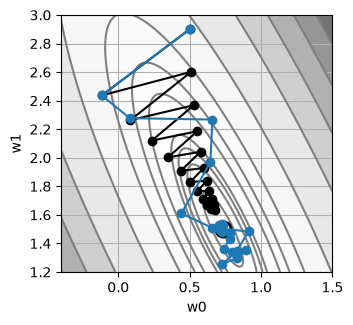

In [41]:
# Punto de inicio
w0 = 0.5
w1 = 2.9

history_dr = {
    "w0": [w0],
    "w1": [w1],
    "sse": [sse(w0, w1)],
}

previous_delta_w0 = 0
previous_delta_w1 = 0

for epoch in range(20):

    w0, w1 = improve(w0, w1, mu=0.03, beta=0.7)

    history_dr["w0"].append(w0)
    history_dr["w1"].append(w1)
    history_dr["sse"].append(sse(w0, w1))

print(" w0 = {:6.4f}\n w1 = {:6.4f}\nSSE = {:6.4f}".format(w0, w1, sse(w0, w1)))

plot_contour()
plt.plot(history_gd["w0"], history_gd["w1"], marker="o", color="black")
plt.plot(history_dr["w0"], history_dr["w1"], marker="o", color="tab:blue")
plt.show()

Es visible que los métodos tienen igual punto de arranque y luego se tienen diferentes direcciones, de tal manera que en menos pasos se llegan a los mismos resultados. De tal manera que **el descenso de la función de error sea más eficiente**. 

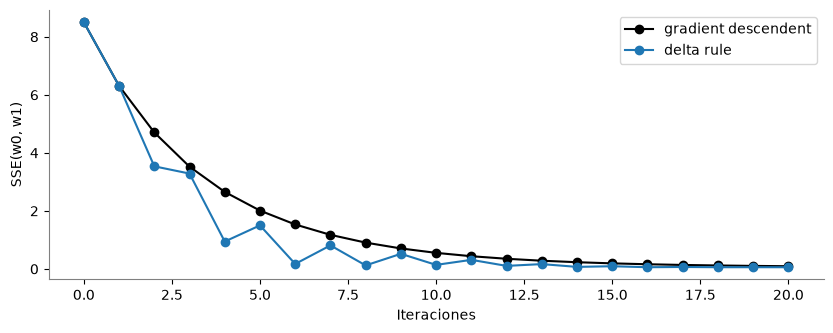

In [42]:
plt.figure(figsize=(10, 3.5))
plt.plot(history_gd["sse"], "o-k", label="gradient descendent")
plt.plot(history_dr["sse"], "o-", color="tab:blue", label="delta rule")
plt.xlabel("Iteraciones")
plt.ylabel("SSE(w0, w1)")
plt.gca().spines["left"].set_color("gray")
plt.gca().spines["bottom"].set_color("gray")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.legend()
plt.show()

Notese que con la regla dela, se desciende más rapido y tiene mejor convergencia. hb

## Algoritmos con supermemoria

En el ejercicio anterior del método delta se ha usado solo 1 dirección previa ahora bien, los algoritmos de supermemoria son algoritmos de estructura similar a la regla delta, pero consideran P valores de $\Delta \mathbf{w}$ hacia atrás.

$$\Delta \mathbf{w}_{k-1} = - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1}) + \sum_{p=0}^P \beta_p \Delta \mathbf{w}_{k-2-p}$$

es como una generalización para que se tomen P direcciones previas (flechas previas). Este ha sido el algoritmo usado en los algoritmos comunes de redes neuronales como los percentrones multicapa y es conocido como back-propagation. Pero esta es la escencia del método.